<a href="https://colab.research.google.com/github/maschu09/mless/blob/main/CNN_classifier_on_remote_sensing_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN classifier for landcover classification from remote sensing images

In this tasks, we will again use the same portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

In this notebook, we will make use of small CNN network on the same subset of SAT-6 dataset that we used in the last exercise

In [1]:
# CNN classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updqated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

def set_reproducible_seed(seed=RANDOM_STATE):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_reproducible_seed()
torch.set_num_threads(max(1, min(4, torch.get_num_threads())))


## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [3]:
# uncomment the following lines if you haven't downloaded the data already
# !mkdir -p data
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv

In [4]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


# Read annotation labels from different csv file

In [5]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: <StringArray>
['building', 'barren_land', 'trees', 'grassland', 'road', 'water']
Length: 6, dtype: str


**Reminder :**  The data structure that you see above is called _one-hot encoding_


In [6]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Plot few samples to see visually the data and gain more insights on how to reshape the 1d data to a 4 channel image (RGB & NIR)

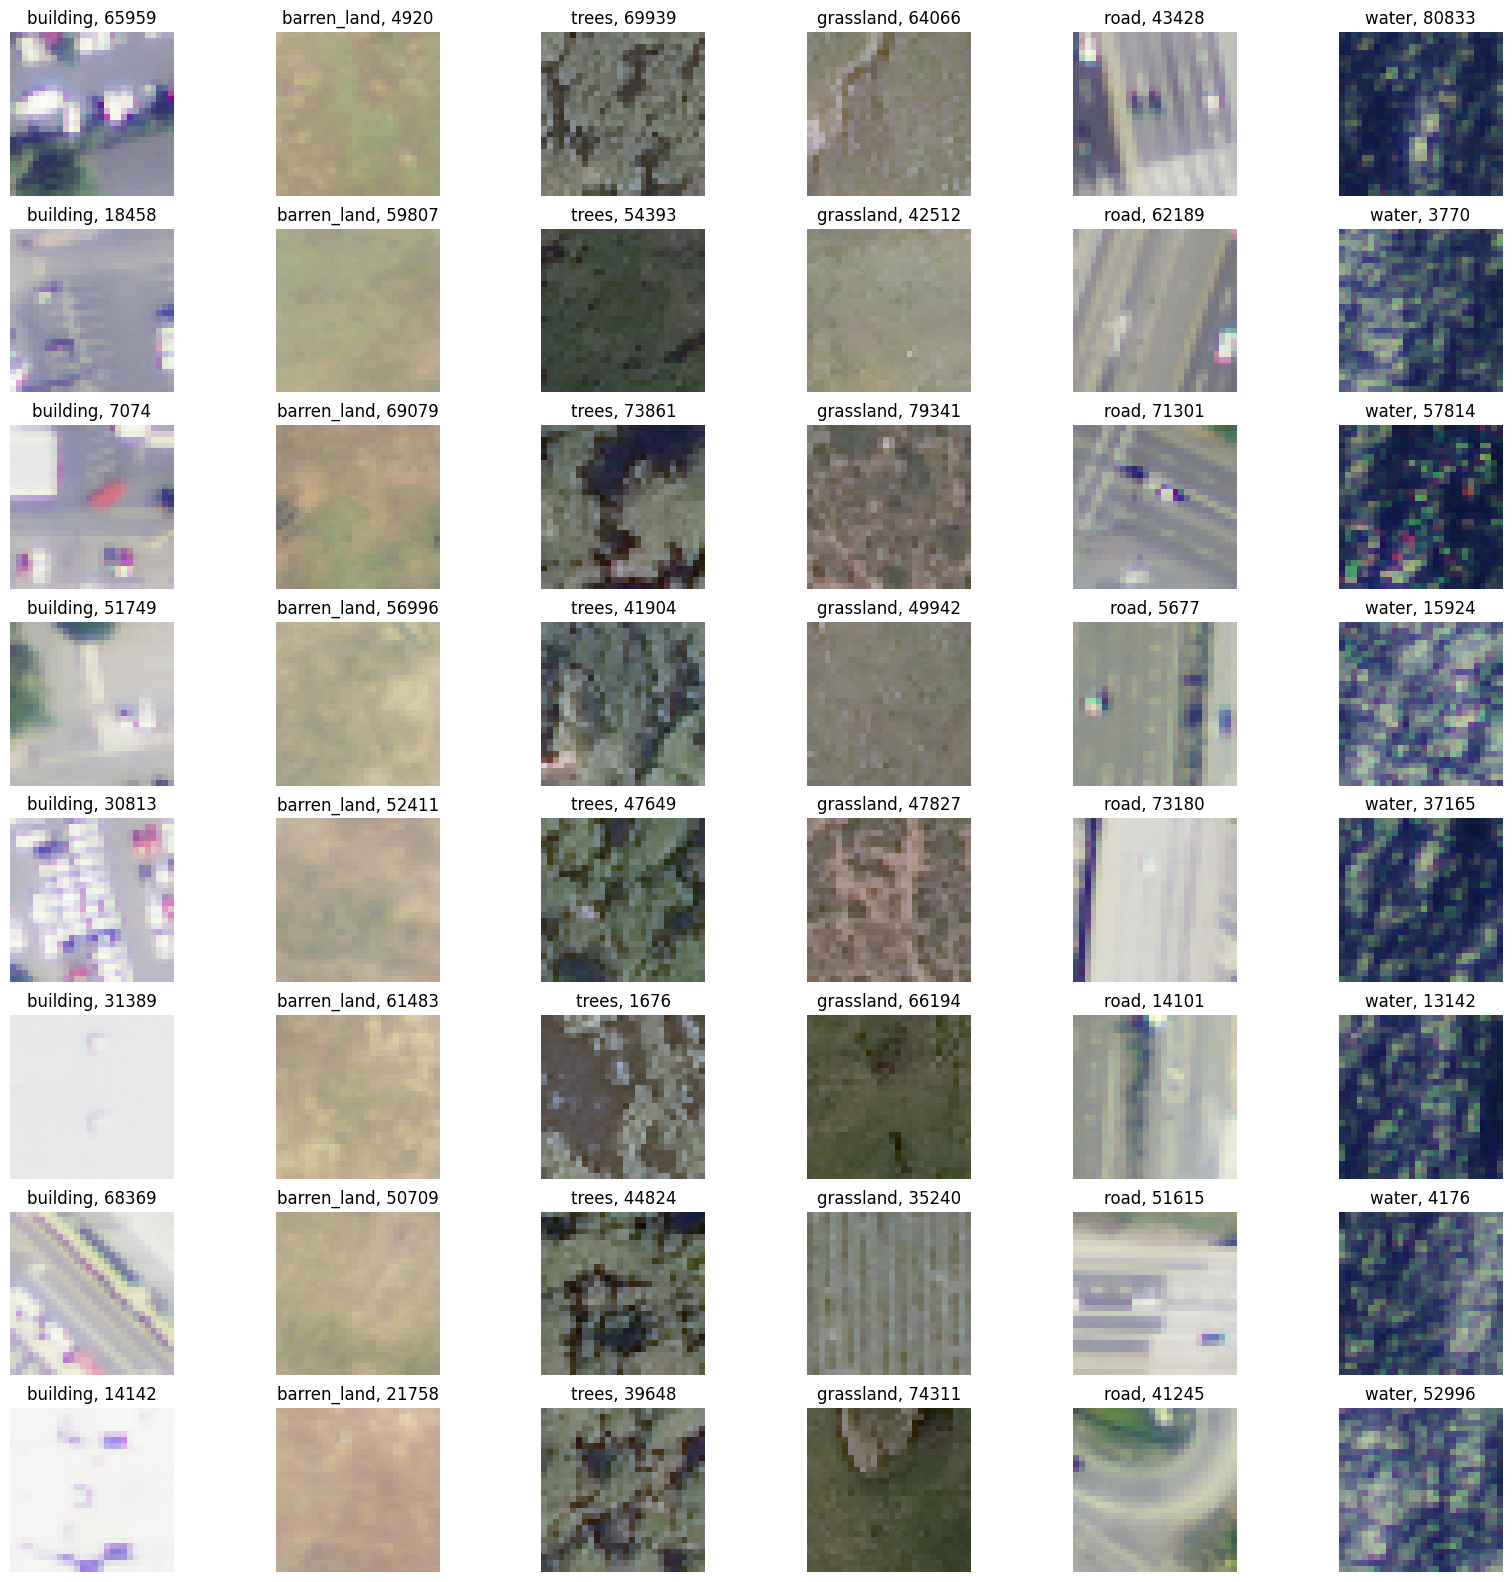

In [7]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

The dataset is not balanced. Use ***num_train*** and ***num_test*** as a definite integer number.

Note: the maximum we tried is ***num_train*** = 2000 and ***num_test*** = 200. Beyond that for some classes, we did not find that many samples

In case you want all samples for training then use ***num_train*** = -1

In [8]:
num_train = 1000 #replace with -1 if all samples need to be used for training
num_test = 100
train_idx = []
test_idx = []
split_rng = np.random.default_rng(RANDOM_STATE + 1)

for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    valid_indices = np.where(class_idx.values)[0]
    random_indices = split_rng.permutation(valid_indices)
    test_idx.extend(random_indices[:num_test].tolist())
    train_idx.extend(random_indices[num_test:num_test + num_train if num_train != -1 else num_train].tolist())

print(f"number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}")


number of train indices: 6000, number of test indices: 600


In [9]:
# Shuffle train and test indices
train_idx = split_rng.permutation(train_idx)
test_idx = split_rng.permutation(test_idx)

# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

overlap = set(train_idx).intersection(set(test_idx))
print(f"train/test overlap: {len(overlap)}")


train/test overlap: 0


# Calculate Normalization Parameter using Train Dataset

In [10]:
def normalization_for_channels(data_df, channel_indices):
    images = data_df.values.reshape((-1, 28, 28, 4))
    selected = images[:, :, :, channel_indices]
    mean_per_channels = np.mean(selected, axis=(0, 1, 2)).astype(np.float32)
    std_per_channels = np.std(selected, axis=(0, 1, 2)).astype(np.float32)
    std_per_channels[std_per_channels == 0] = 1.0
    return mean_per_channels, std_per_channels

all_channels = [0, 1, 2, 3]
rgb_channels = [0, 1, 2]

mean_per_channels, std_per_channels = normalization_for_channels(train_X, all_channels)
mean_per_channels, std_per_channels


(array([132.53827, 132.54645, 129.63716, 120.74164], dtype=float32),
 array([55.644814, 51.195995, 46.892357, 65.42935 ], dtype=float32))

## Define torch dataset

From here, we will make use of general workflow of PyTorch. First thing is to create a dataset. We are making use of mapped-style dataset. [Refer this page for more details](https://pytorch.org/docs/stable/data.html#map-style-datasets)

Important thing is to define the total length under function *__len__* and data corresponding to the index under *__getitem__*

In [11]:
class SAT6Dataset(Dataset):
  def __init__(self, data_df, label_df, normalization_parameter, channels=None):
    super(SAT6Dataset,self).__init__()
    self.channels = [0, 1, 2, 3] if channels is None else channels
    self.normalization = normalization_parameter

    images = data_df.values.reshape((-1, 28, 28, 4)).astype(np.float32)
    self.images = images[:, :, :, self.channels]
    self.labels = label_df.values.argmax(axis=1).astype(np.int64)

  def __len__(self):
    return len(self.images)

  def __getitem__(self,idx):
    data = (self.images[idx]-self.normalization[0])/self.normalization[1]
    data = np.transpose(data,axes=(2,0,1))  # swap dimensions: channel first
    label = self.labels[idx]

    return (data,label)


In [12]:
# define two dataset one for train and other for test
input_channels = [0, 1, 2, 3]
sat6_train_dataset = SAT6Dataset(train_X, train_y, (mean_per_channels, std_per_channels), channels=input_channels)
sat6_test_dataset = SAT6Dataset(test_X, test_y, (mean_per_channels, std_per_channels), channels=input_channels)


Now, we will use **torch.nn.Module** to build our CNN model.

**Important points:**

*   To build modules in a list use **torch.nn.ModuleList()** instead of native list.

*   Define **forward** function to define the step-by-step mathematical transformation




In [13]:
class CNN(torch.nn.Module):
  def __init__(self,
               input_shape,
               num_conv_layers,
               channels_each_layer,
               kernel_size,
               mlp_dimension,
               activation_func,
               pooling,
               input_channels,
               num_classes,
               norm="batch_norm"):
    super(CNN,self).__init__()
    self.num_conv_layers = num_conv_layers
    self.channels_each_layer = channels_each_layer
    assert num_conv_layers == len(channels_each_layer),"Number of conv layers does not match with given number of channels"
    self.kernel_size = ([kernel_size] * num_conv_layers
                        if type(kernel_size) == int
                        else kernel_size)
    self.mlp_dimension = mlp_dimension
    if activation_func == 'relu':
      self.activation_func = torch.nn.ReLU()
    elif activation_func == 'tanh':
      self.activation_func = torch.nn.Tanh()
    else:
      assert False, "Currently only relu and tanh are provided in this code"

    if pooling == "max":
      self.pooling = torch.nn.MaxPool2d(kernel_size=2, stride=2)
    elif pooling == "avg":
      self.pooling = torch.nn.AvgPool2d(kernel_size=2, stride=2)
    else:
      assert False, "Currently only max and avg pooling are provided in this code"

    self.input_channels = input_channels
    if norm=="batch_norm":
      self.batch_norms = [torch.nn.BatchNorm2d(channels_each_layer[i])
                          for i in range(len(self.kernel_size))]
    elif norm == "identity":
      self.batch_norms = [torch.nn.Identity() for i in range(len(self.kernel_size))]
    else:
      assert False,"only batch norm is provided in this code"

    self.conv_modules = torch.nn.ModuleList()

    for i in range(num_conv_layers):
      self.conv_modules.append(
          torch.nn.Conv2d(input_channels if i==0 else channels_each_layer[i-1],
                          channels_each_layer[i],
                          self.kernel_size[i],
                          stride=1,
                          padding='same',
                          bias=True))
      self.conv_modules.append(self.batch_norms[i])
      self.conv_modules.append(self.activation_func)
      self.conv_modules.append(self.pooling)
    dim_after_final_conv_layer = (input_shape[0]//2**num_conv_layers)*(
        input_shape[1]//2**num_conv_layers)*(
            channels_each_layer[-1])
    self.mlp_layer_modules = torch.nn.ModuleList()
    self.mlp_dimension = ([mlp_dimension]
                          if type(mlp_dimension) == int
                          else mlp_dimension)

    for i in range(len(self.mlp_dimension)):
      self.mlp_layer_modules.append(
          torch.nn.Linear((dim_after_final_conv_layer
                           if i==0
                           else self.mlp_dimension[i-1]),
                          self.mlp_dimension[i]))
      # Incase one want to try batch norm uncomment below line
      #self.mlp_layer_modules.append(torch.nn.BatchNorm1d(mlp_dimension[i]))
      self.mlp_layer_modules.append(self.activation_func)
    self.mlp_layer_modules.append(
        torch.nn.Linear(self.mlp_dimension[-1],num_classes))

  def forward(self,x):
    for module in self.conv_modules:
      x = module(x)
    x = x.flatten(1)
    for module in self.mlp_layer_modules:
      x = module(x)
    return x

Define the device (**GPU** if you use GPU as your runtime) else it will run on **CPU**)
Instatiation of the CNN model is also define in this cell

In [14]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn = CNN((28,28),3,[32,64,128],[5,3,3],[32],"relu","max",len(input_channels),6,norm="identity").to(device)


cpu


In [15]:
# Overview of the model
print(cnn)

CNN(
  (activation_func): ReLU()
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_modules): ModuleList(
    (0): Conv2d(4, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (1): Identity()
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): Identity()
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): Identity()
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (mlp_layer_modules): ModuleList(
    (0): Linear(in_features=1152, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=6, bias=True)
  )
)


Define training parameters


*   Optimizer : This reulates the rate of learning. USe wither adam or SGD. For other optimizers, feel free to add them.
*   Scheduler : It updates the learning rate during the training process. We have commented here out. PLease feel free to play with it.
*   Loss function: As it is a multi-class classification problem, CrossEntropy is a suitable loss function.



In [16]:
optim = "adam"
learning_rate = 0.001
loss_fn = torch.nn.CrossEntropyLoss()

Previously, we have defined dataset which takes an index as a parameter and provides data corresponding to the index. In such deep learning problems, we process them in a batch. The DataLoader takes control of such requirements by defining the parameters **batch_size** and **shuffle**.

**Note:**


*   In training, we want each time to have different samples in a batch. The ***shuffle*=True** ensures that. For validation, we do not required such shuffling, hence it is set to False
*   We used the whole length of test dataset as it is small. Incase of any issue with large number of test samples, feel free to decrease the number such as $256$



In [17]:
def make_dataloaders(train_dataset, test_dataset, batch_size=256):
  train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,drop_last=True)
  test_loader = DataLoader(test_dataset,len(test_dataset), shuffle=False)
  return train_loader, test_loader


train_dataloader, test_dataloader = make_dataloaders(sat6_train_dataset, sat6_test_dataset)

# Training Routine
Define number of epochs for the training.


In [18]:
def train_and_evaluate(model, train_loader, test_loader, num_epochs=10, lr=0.001, optim_name="adam"):
  optimizer = torch.optim.Adam(model.parameters(),lr=lr) if optim_name == "adam" else torch.optim.SGD(model.parameters(),lr=lr)
  loss_fn = torch.nn.CrossEntropyLoss()

  history = {
      "train_loss": [],
      "val_loss": [],
      "accuracy": [],
  }

  for i in range(num_epochs):
    model.train()
    for train_data in train_loader:
      optimizer.zero_grad()
      data, batch_labels = train_data
      data = data.to(device)
      batch_labels = batch_labels.to(device)
      preds = model(data)
      train_loss = loss_fn(preds,batch_labels)
      train_loss.backward()
      optimizer.step()

    model.eval()
    pred_labels = []
    true_labels = []
    with torch.no_grad():
      for test_data in test_loader:
        data, batch_labels = test_data
        data = data.to(device)
        batch_labels = batch_labels.to(device)
        preds = model(data)
        val_loss = loss_fn(preds,batch_labels)
        pred_labels.extend(torch.argmax(preds,dim=1).detach().cpu().numpy().tolist())
        true_labels.extend(batch_labels.detach().cpu().numpy().tolist())

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())
    acc = accuracy_score(true_labels,pred_labels)
    history["accuracy"].append(acc)
    print(
        f"epoch {i+1:02d}/{num_epochs}: "
        f"train_loss={train_loss.item():.4f}, "
        f"val_loss={val_loss.item():.4f}, "
        f"accuracy={acc:.3f}"
    )

  return history, np.array(true_labels), np.array(pred_labels)


num_epochs = 10
set_reproducible_seed(RANDOM_STATE + 10)
history, cnn_true_labels, cnn_pred_labels = train_and_evaluate(
    cnn,
    train_dataloader,
    test_dataloader,
    num_epochs=num_epochs,
    lr=learning_rate,
    optim_name=optim,
)

training_loss_per_epoch = history["train_loss"]
validation_loss_per_epoch = history["val_loss"]
acc_per_epoch = history["accuracy"]


epoch 01/10: train_loss=0.4915, val_loss=0.5201, accuracy=0.813


epoch 02/10: train_loss=0.3549, val_loss=0.3518, accuracy=0.870


epoch 03/10: train_loss=0.2752, val_loss=0.2662, accuracy=0.915


epoch 04/10: train_loss=0.2188, val_loss=0.2218, accuracy=0.932


epoch 05/10: train_loss=0.1308, val_loss=0.1631, accuracy=0.948


epoch 06/10: train_loss=0.1398, val_loss=0.1554, accuracy=0.945


epoch 07/10: train_loss=0.1729, val_loss=0.2342, accuracy=0.942


epoch 08/10: train_loss=0.1367, val_loss=0.1346, accuracy=0.958


epoch 09/10: train_loss=0.0893, val_loss=0.1301, accuracy=0.963


epoch 10/10: train_loss=0.0990, val_loss=0.1174, accuracy=0.962


The variables **training_loss_per_epoch**, **validation_loss_per_epoch**, and **acc_per_epoch** contains metrics after each epoch. Try to plot them to see how was the progress during training.

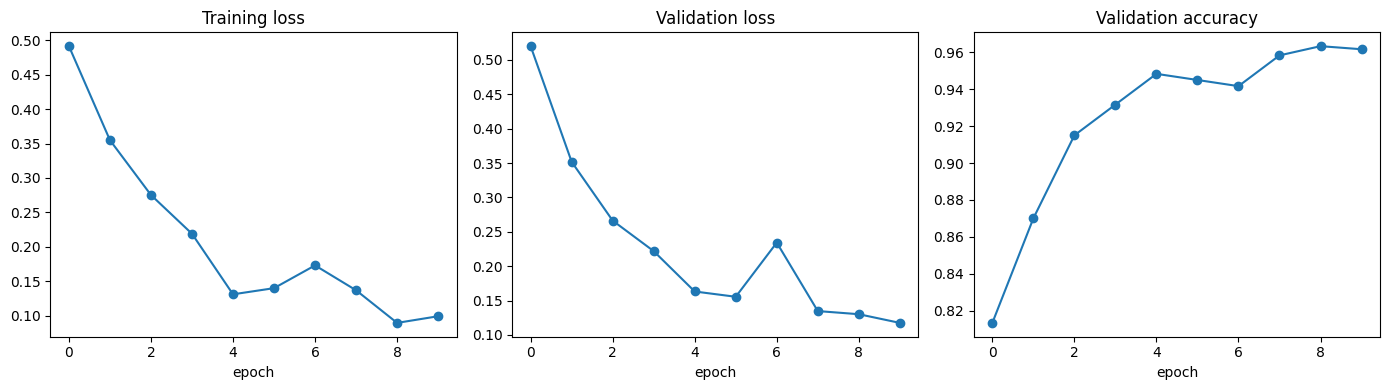

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].plot(training_loss_per_epoch, marker="o")
ax[0].set_title("Training loss")
ax[0].set_xlabel("epoch")

ax[1].plot(validation_loss_per_epoch, marker="o")
ax[1].set_title("Validation loss")
ax[1].set_xlabel("epoch")

ax[2].plot(acc_per_epoch, marker="o")
ax[2].set_title("Validation accuracy")
ax[2].set_xlabel("epoch")

plt.tight_layout()
plt.show()


CNN with R, G, B, and NIR overall accuracy: 0.962
  building: 0.960
  barren_land: 0.970
  trees: 0.960
  grassland: 0.920
  road: 0.960
  water: 1.000


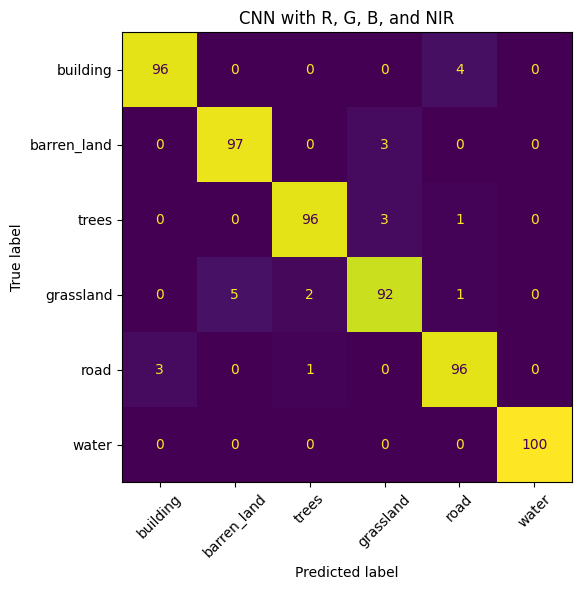

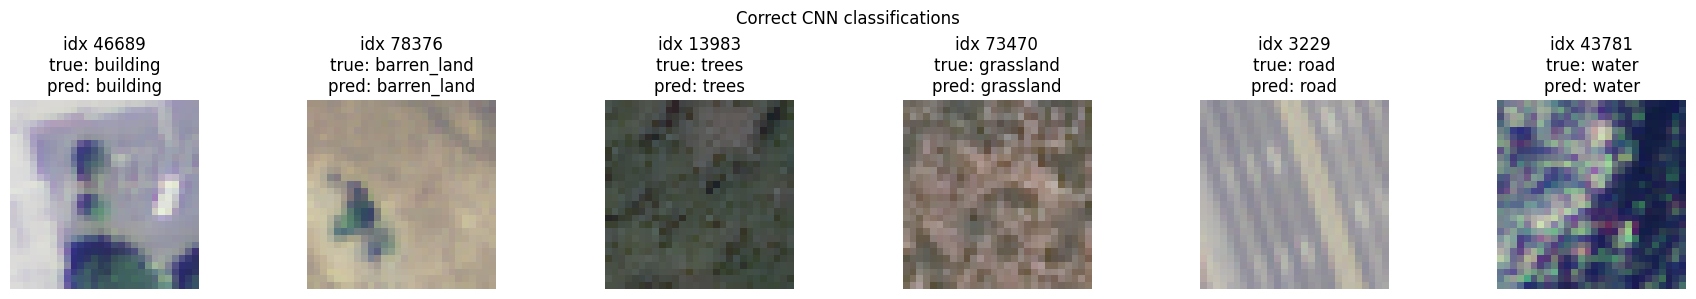

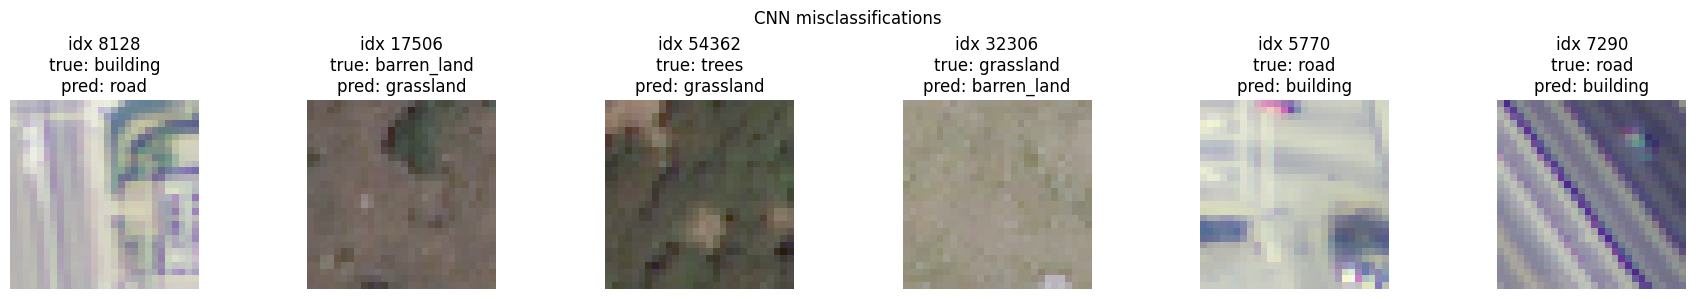

In [20]:
def evaluate_cnn(model, dataloader, class_labels, title):
    model.eval()
    true_labels = []
    pred_labels = []

    with torch.no_grad():
      for data, labels in dataloader:
        data = data.to(device)
        labels = labels.to(device)
        preds = model(data)
        pred_labels.extend(torch.argmax(preds, dim=1).to("cpu").numpy().tolist())
        true_labels.extend(labels.to("cpu").numpy().tolist())

    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)
    accuracy = accuracy_score(true_labels, pred_labels)
    cm = confusion_matrix(true_labels, pred_labels, labels=np.arange(len(class_labels)))
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

    print(f"{title} overall accuracy: {accuracy:.3f}")
    for label, score in zip(class_labels, per_class_accuracy):
        print(f"  {label}: {score:.3f}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return accuracy, per_class_accuracy, cm, true_labels, pred_labels

def choose_cnn_example_indices(true_labels, pred_labels, correct=True, max_examples=6):
    matches = true_labels == pred_labels if correct else true_labels != pred_labels
    candidates = np.where(matches)[0]
    if len(candidates) == 0:
      return candidates

    chosen = []
    for class_id in range(len(labels)):
      class_candidates = candidates[true_labels[candidates] == class_id]
      if len(class_candidates) > 0:
        chosen.append(class_candidates[0])
      if len(chosen) == max_examples:
        break

    if len(chosen) < max_examples:
      for candidate in candidates:
        if candidate not in chosen:
          chosen.append(candidate)
        if len(chosen) == max_examples:
          break

    return np.array(chosen)

def plot_cnn_examples(data_df, true_labels, pred_labels, class_labels,
                      title, correct=True, max_examples=6):
    example_idx = choose_cnn_example_indices(true_labels, pred_labels, correct, max_examples)

    if len(example_idx) == 0:
      print(f"No examples found for: {title}")
      return

    fig, axes = plt.subplots(1, len(example_idx), figsize=(3 * len(example_idx), 3))
    if len(example_idx) == 1:
      axes = [axes]

    for ax, local_idx in zip(axes, example_idx):
      original_idx = test_idx[local_idx]
      image = data_df.iloc[local_idx].values.reshape((28, 28, 4))
      ax.imshow(image[:, :, :3])
      ax.axis("off")
      ax.set_title(
          f"idx {original_idx}\n"
          f"true: {class_labels[true_labels[local_idx]]}\n"
          f"pred: {class_labels[pred_labels[local_idx]]}"
      )

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

cnn_metrics = evaluate_cnn(cnn, test_dataloader, labels, "CNN with R, G, B, and NIR")
_, _, _, cnn_true_labels, cnn_pred_labels = cnn_metrics

plot_cnn_examples(test_X, cnn_true_labels, cnn_pred_labels, labels,
                  "Correct CNN classifications", correct=True)
plot_cnn_examples(test_X, cnn_true_labels, cnn_pred_labels, labels,
                  "CNN misclassifications", correct=False)


## RGB-only CNN experiment

For the CNN the main code change is not only the feature matrix. The dataset has to return fewer channels, the normalization statistics must be recalculated for those channels, and the first convolution layer must be created with input_channels=3.


CNN with RGB only


epoch 01/10: train_loss=0.5935, val_loss=0.5400, accuracy=0.830


epoch 02/10: train_loss=0.3280, val_loss=0.2834, accuracy=0.882


epoch 03/10: train_loss=0.2825, val_loss=0.2142, accuracy=0.927


epoch 04/10: train_loss=0.1822, val_loss=0.2380, accuracy=0.898


...

epoch 06/10: train_loss=0.1748, val_loss=0.1888, accuracy=0.930


epoch 07/10: train_loss=0.1747, val_loss=0.1545, accuracy=0.938


epoch 08/10: train_loss=0.2000, val_loss=0.1809, accuracy=0.930


epoch 09/10: train_loss=0.1102, val_loss=0.1335, accuracy=0.953


epoch 10/10: train_loss=0.1194, val_loss=0.1324, accuracy=0.952
CNN with RGB only overall accuracy: 0.952
  building: 0.880
  barren_land: 0.940
  trees: 0.970
  grassland: 0.930
  road: 0.990
  water: 1.000


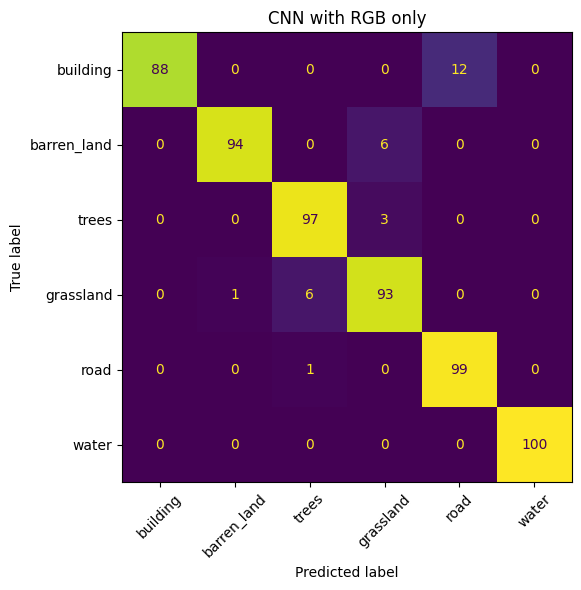

In [21]:
def train_cnn_experiment(channels, learning_rate=0.001, epochs=10, title="CNN experiment", seed=RANDOM_STATE):
    set_reproducible_seed(seed)
    mean_channels, std_channels = normalization_for_channels(train_X, channels)

    train_dataset = SAT6Dataset(train_X, train_y, (mean_channels, std_channels), channels=channels)
    test_dataset = SAT6Dataset(test_X, test_y, (mean_channels, std_channels), channels=channels)

    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, len(test_dataset), shuffle=False)

    model = CNN((28, 28), 3, [32, 64, 128], [5, 3, 3], [32], "relu",
                "max", len(channels), 6, norm="identity").to(device)

    print(title)
    history, true_labels, pred_labels = train_and_evaluate(
        model,
        train_loader,
        test_loader,
        num_epochs=epochs,
        lr=learning_rate,
        optim_name="adam"
    )

    metrics = evaluate_cnn(model, test_loader, labels, title)
    return model, history, metrics

rgb_cnn, rgb_history, rgb_cnn_metrics = train_cnn_experiment(
    channels=[0, 1, 2],
    learning_rate=0.001,
    epochs=10,
    title="CNN with RGB only",
    seed=RANDOM_STATE + 20
)


## CNN hyperparameter experiment

I changed the learning rate from 0.001 to 0.0005. My expectation was that a smaller learning rate would make the training updates more careful and stable, but after only 10 epochs it might learn more slowly and therefore score a bit lower.


CNN with learning_rate=0.0005


epoch 01/10: train_loss=0.6849, val_loss=0.6334, accuracy=0.815


epoch 02/10: train_loss=0.3914, val_loss=0.3999, accuracy=0.833


epoch 03/10: train_loss=0.3291, val_loss=0.3450, accuracy=0.872


epoch 04/10: train_loss=0.2740, val_loss=0.2901, accuracy=0.902


...

epoch 06/10: train_loss=0.2185, val_loss=0.1606, accuracy=0.953


epoch 07/10: train_loss=0.1615, val_loss=0.1471, accuracy=0.962


epoch 08/10: train_loss=0.1215, val_loss=0.1261, accuracy=0.968


epoch 09/10: train_loss=0.0941, val_loss=0.1397, accuracy=0.965


epoch 10/10: train_loss=0.1313, val_loss=0.1311, accuracy=0.958
CNN with learning_rate=0.0005 overall accuracy: 0.958
  building: 0.960
  barren_land: 0.950
  trees: 0.980
  grassland: 0.890
  road: 0.970
  water: 1.000


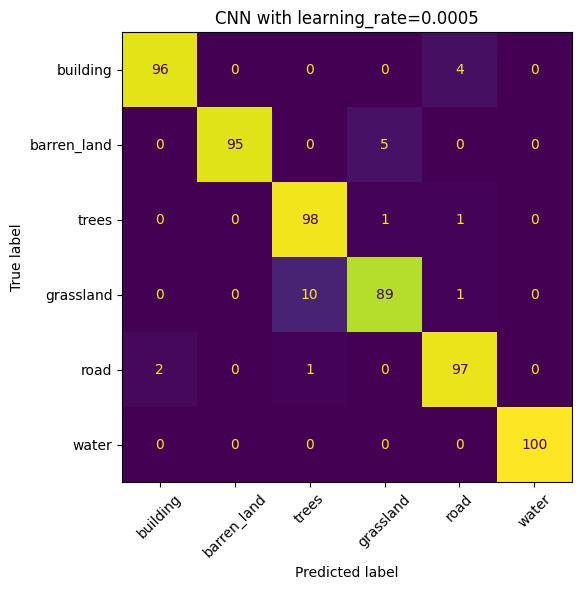

In [22]:
cnn_lr0005, lr0005_history, lr0005_metrics = train_cnn_experiment(
    channels=[0, 1, 2, 3],
    learning_rate=0.0005,
    epochs=10,
    title="CNN with learning_rate=0.0005",
    seed=RANDOM_STATE + 10
)
